In [ ]:
import pandas as pd
import numpy as np
import joblib
import os
import sys

# Library Machine Learning
from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      accuracy_score, f1_score)
from sklearn.pipeline         import Pipeline

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


In [ ]:
df = pd.read_csv('../ml-backend/data/features_dataset.csv')

print(f"Shape dataset  : {df.shape}")
print(f"Jumlah fitur   : {df.shape[1] - 1}")
print(f"\nDistribusi label:")
print(df['label'].value_counts().rename({0:'Aman', 1:'Phishing', 2:'Judi Online'}))
print(f"\nAda nilai kosong?: {df.isnull().sum().sum()}")

Shape dataset  : (10910, 21)
Jumlah fitur   : 20

Distribusi label:
label
Aman           5000
Phishing       3000
Judi Online    2910
Name: count, dtype: int64

Ada nilai kosong?: 0


In [ ]:
FEATURE_COLUMNS = [
    'url_length', 'has_https', 'dot_count', 'hyphen_count',
    'at_count', 'double_slash', 'digit_count', 'domain_length',
    'path_depth', 'has_query', 'has_suspicious_tld', 'has_ip',
    'has_phishing_keyword', 'has_gambling_keyword', 'has_brand_spoofing',
    'subdomain_length', 'subdomain_count', 'domain_entropy',
    'special_chars', 'path_length'
]

X = df[FEATURE_COLUMNS]
y = df['label']

print(f"Shape X (fitur) : {X.shape}")
print(f"Shape y (label) : {y.shape}")
print(f"\n3 baris pertama X:")
X.head(3)

Shape X (fitur) : (10910, 20)
Shape y (label) : (10910,)

Contoh X (3 baris pertama):


,url_length,has_https,dot_count,hyphen_count,at_count,double_slash,digit_count,domain_length,path_depth,has_query,has_suspicious_tld,has_ip,has_phishing_keyword,has_gambling_keyword,has_brand_spoofing,subdomain_length,subdomain_count,domain_entropy,special_chars,path_length
0,19,1,1,0,0,1,0,7,0,0,0,0,0,0,0,0,0,2.8074,0,0
1,19,1,1,0,0,1,4,7,0,0,0,0,0,0,0,0,0,2.5216,0,0
2,22,1,1,0,0,1,0,11,0,0,0,0,0,0,0,0,0,2.9140,0,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = 42
)

print(f"Data training : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Data testing  : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nDistribusi label di training set:")
print(y_train.value_counts())

Data training : 8728 baris (80%)
Data testing  : 2182 baris (20%)

Distribusi label di training set:
label
0    4000
1    2400
2    2328
Name: count, dtype: int64


In [ ]:
print("Melatih Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators     = 100,
    max_depth        = 20,
    min_samples_split= 5,
    min_samples_leaf = 2,
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)

rf_model.fit(X_train, y_train)

# Evaluasi di data test
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted')

print(f"\n✅ Random Forest selesai dilatih!")
print(f"   Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)")
print(f"   F1-Score : {rf_f1:.4f}")

Melatih Random Forest... (mungkin 30-60 detik)

✅ Random Forest selesai dilatih!
   Accuracy : 0.9918 (99.18%)
   F1-Score : 0.9918


In [ ]:
print("Melatih Logistic Regression...")

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        max_iter     = 1000,
        C            = 1.0,
        class_weight = 'balanced',
        random_state = 42,
        n_jobs       = -1
    ))
])

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='weighted')

print(f"\n✅ Logistic Regression selesai dilatih!")
print(f"   Accuracy : {lr_acc:.4f} ({lr_acc*100:.2f}%)")
print(f"   F1-Score : {lr_f1:.4f}")

Melatih Logistic Regression...

✅ Logistic Regression selesai dilatih!
   Accuracy : 0.9844 (98.44%)
   F1-Score : 0.9844


c:\Dev\project\web\NETRA\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [ ]:
print("Membuat Hybrid Ensemble Model...")

hybrid_model = VotingClassifier(
    estimators = [
        ('random_forest', rf_model),
        ('logistic_reg',  lr_pipeline)
    ],
    voting  = 'soft',
    weights = [2, 1]
)

hybrid_model.fit(X_train, y_train)

hybrid_pred = hybrid_model.predict(X_test)
hybrid_acc  = accuracy_score(y_test, hybrid_pred)
hybrid_f1   = f1_score(y_test, hybrid_pred, average='weighted')

print(f"\n✅ Hybrid Model selesai dibuat!")
print(f"   Accuracy : {hybrid_acc:.4f} ({hybrid_acc*100:.2f}%)")
print(f"   F1-Score : {hybrid_f1:.4f}")

Membuat Hybrid Ensemble Model...

✅ Hybrid Model selesai dibuat!
   Accuracy : 0.9899 (98.99%)
   F1-Score : 0.9899


c:\Dev\project\web\NETRA\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Model                       Accuracy   F1-Score
Random Forest                 0.9918     0.9918
Logistic Regression           0.9844     0.9844
Hybrid (Ensemble)             0.9899     0.9899


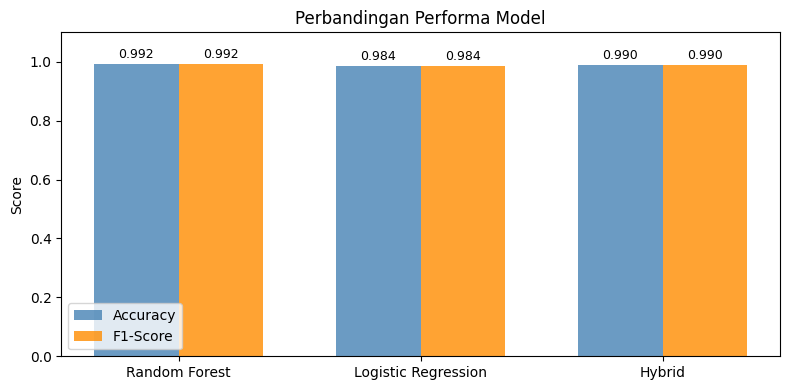

In [ ]:
print("=" * 50)
print(f"{'Model':<25} {'Accuracy':>10} {'F1-Score':>10}")
print("=" * 50)
print(f"{'Random Forest':<25} {rf_acc:>10.4f} {rf_f1:>10.4f}")
print(f"{'Logistic Regression':<25} {lr_acc:>10.4f} {lr_f1:>10.4f}")
print(f"{'Hybrid (Ensemble)':<25} {hybrid_acc:>10.4f} {hybrid_f1:>10.4f}")
print("=" * 50)

# Visualisasi perbandingan
fig, ax = plt.subplots(figsize=(8, 4))
models    = ['Random Forest', 'Logistic Regression', 'Hybrid']
acc_vals  = [rf_acc, lr_acc, hybrid_acc]
f1_vals   = [rf_f1,  lr_f1,  hybrid_f1]
x = np.arange(len(models))
w = 0.35

bars1 = ax.bar(x - w/2, acc_vals, w, label='Accuracy', color='steelblue',  alpha=0.8)
bars2 = ax.bar(x + w/2, f1_vals,  w, label='F1-Score',  color='darkorange', alpha=0.8)

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../dataset/model_comparison.png', dpi=100)
plt.show()

=== LAPORAN DETAIL HYBRID MODEL ===

                 precision    recall  f1-score   support

       Aman (0)       0.99      0.99      0.99      1000
   Phishing (1)       1.00      0.99      0.99       600
Judi Online (2)       0.98      0.99      0.98       582

       accuracy                           0.99      2182
      macro avg       0.99      0.99      0.99      2182
   weighted avg       0.99      0.99      0.99      2182



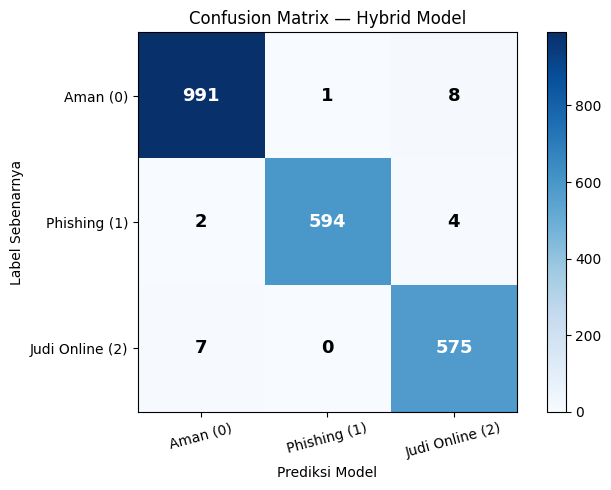

In [ ]:
# Classification Report → precision, recall, F1 per kelas
label_names = ['Aman (0)', 'Phishing (1)', 'Judi Online (2)']

print("=== LAPORAN DETAIL HYBRID MODEL ===\n")
print(classification_report(y_test, hybrid_pred, target_names=label_names))

# Confusion Matrix → tabel prediksi benar vs salah
cm = confusion_matrix(y_test, hybrid_pred)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(label_names, rotation=15)
ax.set_yticklabels(label_names)
ax.set_xlabel('Prediksi Model')
ax.set_ylabel('Label Sebenarnya')
ax.set_title('Confusion Matrix — Hybrid Model')

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=13, fontweight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.savefig('../dataset/confusion_matrix.png', dpi=100)
plt.show()

In [ ]:
print("Menjalankan 5-Fold Cross Validation...")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(rf_model, X, y, cv=cv,
                                scoring='f1_weighted', n_jobs=-1)

print(f"\nRandom Forest Cross-Validation F1:")
print(f"  Tiap fold : {rf_cv_scores.round(4)}")
print(f"  Rata-rata : {rf_cv_scores.mean():.4f} (±{rf_cv_scores.std():.4f})")
print(f"\n→ Semakin kecil std (±), semakin stabil modelnya")

Menjalankan 5-Fold Cross Validation... (butuh 1-2 menit)

Random Forest Cross-Validation F1:
  Tiap fold : [0.9849 0.9881 0.9881 0.9876 0.9886]
  Rata-rata : 0.9875 (±0.0013)

→ Semakin kecil std (±), semakin stabil modelnya


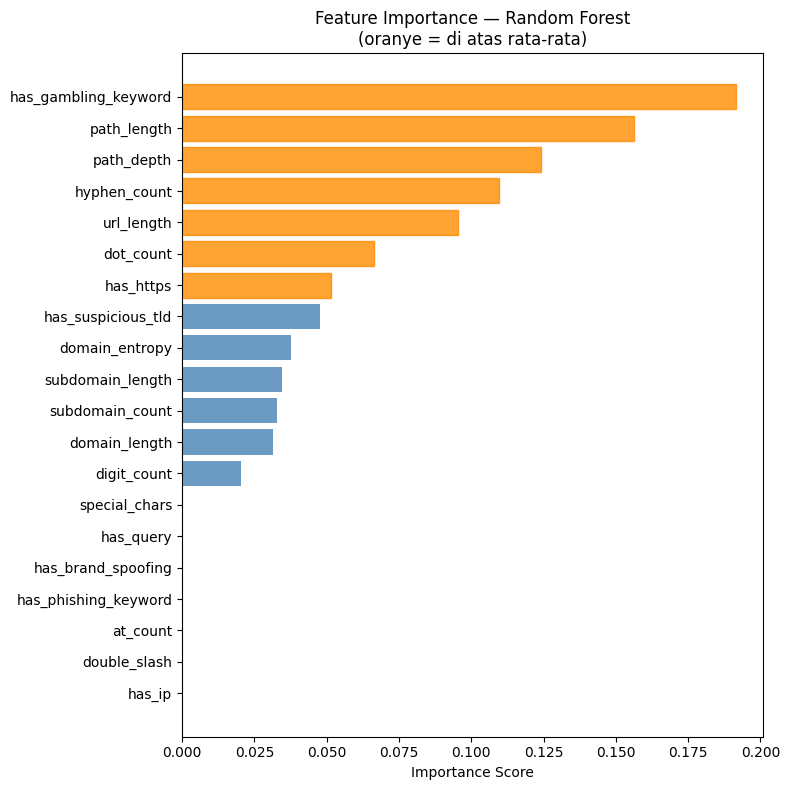


Top 5 fitur paling penting:
  has_gambling_keyword      0.1914  ██████████████████████████████████████
  path_length               0.1562  ███████████████████████████████
  path_depth                0.1242  ████████████████████████
  hyphen_count              0.1095  █████████████████████
  url_length                0.0954  ███████████████████


In [ ]:
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({
    'fitur'      : FEATURE_COLUMNS,
    'importance' : importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
bars = ax.barh(fi_df['fitur'], fi_df['importance'],
               color='steelblue', alpha=0.8)

for i, bar in enumerate(bars):
    if fi_df['importance'].iloc[i] > fi_df['importance'].mean():
        bar.set_color('darkorange')

ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest\n(oranye = di atas rata-rata)')
plt.tight_layout()
plt.savefig('../dataset/feature_importance.png', dpi=100)
plt.show()

print("\nTop 5 fitur paling penting:")
top5 = fi_df.sort_values('importance', ascending=False).head(5)
for _, row in top5.iterrows():
    bar = '█' * int(row['importance'] * 200)
    print(f"  {row['fitur']:<25} {row['importance']:.4f}  {bar}")

In [ ]:
os.makedirs('../ml-backend/models', exist_ok=True)

joblib.dump(rf_model,      '../ml-backend/models/random_forest.pkl')
joblib.dump(lr_pipeline,   '../ml-backend/models/logistic_regression.pkl')
joblib.dump(hybrid_model,  '../ml-backend/models/hybrid_model.pkl')

joblib.dump(FEATURE_COLUMNS, '../ml-backend/models/feature_columns.pkl')

print("✅ Semua model berhasil disimpan!")
print("\nFile yang tersimpan:")
for f in os.listdir('../ml-backend/models'):
    size = os.path.getsize(f'../ml-backend/models/{f}') / 1024
    print(f"  {f:<35} {size:.1f} KB")

✅ Semua model berhasil disimpan!

File yang tersimpan:
  feature_columns.pkl                 0.3 KB
  hybrid_model.pkl                    4650.6 KB
  isolation_forest.pkl                1395.2 KB
  logistic_regression.pkl             2.8 KB
  random_forest.pkl                   2323.1 KB
  scaler_isolation.pkl                1.6 KB


In [ ]:
from sklearn.ensemble    import IsolationForest
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import joblib
import os

df = pd.read_csv('../ml-backend/data/features_dataset.csv')

FEATURE_COLUMNS = [
    'url_length', 'has_https', 'dot_count', 'hyphen_count',
    'at_count', 'double_slash', 'digit_count', 'domain_length',
    'path_depth', 'has_query', 'has_suspicious_tld', 'has_ip',
    'has_phishing_keyword', 'has_gambling_keyword', 'has_brand_spoofing',
    'subdomain_length', 'subdomain_count', 'domain_entropy',
    'special_chars', 'path_length'
]

df_aman = df[df['label'] == 0].copy()
X_aman  = df_aman[FEATURE_COLUMNS]

print(f"Total URL aman untuk training IF : {len(X_aman)}")
print(f"Jumlah fitur                      : {X_aman.shape[1]}")
print(f"\nContoh statistik URL aman:")
print(X_aman[['url_length', 'has_https', 'domain_entropy', 'dot_count']].describe().round(2))

Total URL aman untuk training IF : 5000
Jumlah fitur                      : 20

Contoh statistik URL aman:
       url_length  has_https  domain_entropy  dot_count
count     5000.00     5000.0         5000.00    5000.00
mean        19.96        1.0            2.42       1.10
std          3.60        0.0            0.65       0.31
min         12.00        1.0            0.00       1.00
25%         17.00        1.0            2.00       1.00
50%         20.00        1.0            2.52       1.00
75%         22.00        1.0            2.92       1.00
max         51.00        1.0            3.73       3.00


In [ ]:
scaler_if = StandardScaler()

X_aman_scaled = scaler_if.fit_transform(X_aman)

print("Sebelum scaling (url_length):")
print(f"  Mean: {X_aman['url_length'].mean():.1f}")
print(f"  Std : {X_aman['url_length'].std():.1f}")
print(f"  Min : {X_aman['url_length'].min()}")
print(f"  Max : {X_aman['url_length'].max()}")

print("\nSetelah scaling (url_length):")
print(f"  Mean: {X_aman_scaled[:, 0].mean():.4f} (mendekati 0)")
print(f"  Std : {X_aman_scaled[:, 0].std():.4f}  (mendekati 1)")

Sebelum scaling (url_length):
  Mean: 20.0
  Std : 3.6
  Min : 12
  Max : 51

Setelah scaling (url_length):
  Mean: -0.0000 (mendekati 0)
  Std : 1.0000  (mendekati 1)


In [ ]:
print("Melatih Isolation Forest...")

# Parameter Isolation Forest:
iso_forest = IsolationForest(
    n_estimators  = 200,
    contamination = 0.05,
    max_samples   = 'auto',
    max_features  = 1.0,
    random_state  = 42,
    n_jobs        = -1
)

iso_forest.fit(X_aman_scaled)

print("✅ Isolation Forest selesai dilatih!")
print(f"   Dilatih dari: {len(X_aman_scaled)} URL aman")
print(f"   Jumlah pohon: {iso_forest.n_estimators}")

Melatih Isolation Forest...
✅ Isolation Forest selesai dilatih!
   Dilatih dari: 5000 URL aman
   Jumlah pohon: 200


In [ ]:
X_semua = df[FEATURE_COLUMNS]
y_semua = df['label']

X_semua_scaled = scaler_if.transform(X_semua)

# Prediksi Isolation Forest:
# predict()        → -1 = anomali (mencurigakan), +1 = normal
# score_samples()  → semakin negatif = semakin anomali
prediksi_if    = iso_forest.predict(X_semua_scaled)
skor_anomali   = iso_forest.score_samples(X_semua_scaled)

# Konversi: -1 → 1 (anomali=True), +1 → 0 (normal=False)
is_anomali = (prediksi_if == -1).astype(int)

# Evaluasi per kategori label
print("═" * 55)
print("Hasil Deteksi Isolation Forest per Kategori URL")
print("═" * 55)

for label, nama in [(0, 'Aman'), (1, 'Phishing'), (2, 'Judi Online')]:
    mask          = y_semua == label
    total         = mask.sum()
    terdeteksi    = is_anomali[mask].sum()
    persen        = terdeteksi / total * 100
    skor_rata     = skor_anomali[mask].mean()

    bar = '█' * int(persen / 5)
    print(f"\n{nama} (total: {total})")
    print(f"  Terdeteksi anomali : {terdeteksi}/{total} ({persen:.1f}%)")
    print(f"  Rata-rata skor     : {skor_rata:.4f}")
    print(f"  {bar}")

print("\n─" * 55)
print("Interpretasi:")
print("  URL Aman       → idealnya RENDAH terdeteksi anomali")
print("  URL Phishing   → idealnya TINGGI terdeteksi anomali")
print("  URL Judi       → idealnya TINGGI terdeteksi anomali")

═══════════════════════════════════════════════════════
Hasil Deteksi Isolation Forest per Kategori URL
═══════════════════════════════════════════════════════

Aman (total: 5000)
  Terdeteksi anomali : 250/5000 (5.0%)
  Rata-rata skor     : -0.3950
  █

Phishing (total: 3000)
  Terdeteksi anomali : 2598/3000 (86.6%)
  Rata-rata skor     : -0.6524
  █████████████████

Judi Online (total: 2910)
  Terdeteksi anomali : 2226/2910 (76.5%)
  Rata-rata skor     : -0.5955
  ███████████████

─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
─
Interpretasi:
  URL Aman       → idealnya RENDAH terdeteksi anomali
  URL Phishing   → idealnya TINGGI terdeteksi anomali
  URL Judi       → idealnya TINGGI terdeteksi anomali


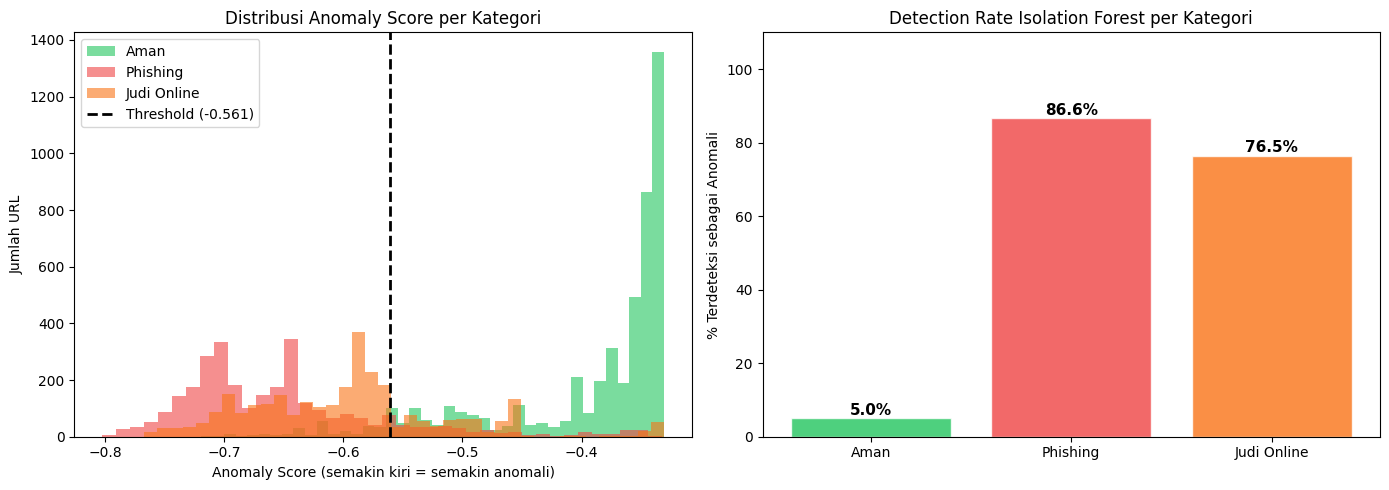

Grafik disimpan → dataset/isolation_forest_eval.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Distribusi anomaly score per kategori
ax1 = axes[0]

warna  = {0: '#22c55e', 1: '#ef4444', 2: '#f97316'}
labels = {0: 'Aman', 1: 'Phishing', 2: 'Judi Online'}

for label in [0, 1, 2]:
    mask  = y_semua == label
    skor  = skor_anomali[mask]
    ax1.hist(skor, bins=40, alpha=0.6,
             color=warna[label], label=labels[label])

threshold = iso_forest.offset_
ax1.axvline(threshold, color='black', linestyle='--',
            linewidth=2, label=f'Threshold ({threshold:.3f})')

ax1.set_xlabel('Anomaly Score (semakin kiri = semakin anomali)')
ax1.set_ylabel('Jumlah URL')
ax1.set_title('Distribusi Anomaly Score per Kategori')
ax1.legend()

# Plot 2: Detection rate per kategori
ax2 = axes[1]

kategori_nama = ['Aman', 'Phishing', 'Judi Online']
detection_rates = []

for label in [0, 1, 2]:
    mask  = y_semua == label
    rate  = is_anomali[mask].mean() * 100
    detection_rates.append(rate)

bars = ax2.bar(kategori_nama, detection_rates,
               color=['#22c55e', '#ef4444', '#f97316'],
               alpha=0.8, edgecolor='white')

for bar, rate in zip(bars, detection_rates):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax2.set_ylabel('% Terdeteksi sebagai Anomali')
ax2.set_title('Detection Rate Isolation Forest per Kategori')
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.savefig('../dataset/isolation_forest_eval.png', dpi=100)
plt.show()

print("Grafik disimpan → dataset/isolation_forest_eval.png")

In [ ]:
joblib.dump(iso_forest,  '../ml-backend/models/isolation_forest.pkl')
joblib.dump(scaler_if,   '../ml-backend/models/scaler_isolation.pkl')

print("✅ Model tersimpan:")
print(f"   → models/isolation_forest.pkl")
print(f"   → models/scaler_isolation.pkl")

for f in ['isolation_forest.pkl', 'scaler_isolation.pkl']:
    path = f'../ml-backend/models/{f}'
    size = os.path.getsize(path) / 1024
    print(f"   {f}: {size:.1f} KB ✓")

✅ Model tersimpan:
   → models/isolation_forest.pkl
   → models/scaler_isolation.pkl
   isolation_forest.pkl: 1395.2 KB ✓
   scaler_isolation.pkl: 1.6 KB ✓
